# Image Classification Using Convolutional Neural Networks (CNNs) on the CIFAR-10 Dataset

## Week 6 Internship Task – Computer Vision with CIFAR-10

### AnalystLab Africa AI Internship Program (Batch B)

This project explores Computer Vision using the CIFAR-10 dataset. A Convolutional Neural Network (CNN) was developed to classify images into ten categories, including airplanes, automobiles, birds, cats, dogs, ships, and trucks. The model was trained and evaluated using various performance metrics, including accuracy, loss curves, a classification report, and a confusion matrix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

## 2. Loading the CIFAR-10 Dataset

The CIFAR-10 dataset consists of 60,000 color images divided into 10 classes. The dataset is split into 50,000 training images and 10,000 testing images.

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4522s 27us/step


## 3. Exploring the Dataset

The dataset dimensions are examined to understand the number of samples, image size, and color channels available for model training and evaluation.

In [3]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)


## 4. Visualizing Sample Images

A sample of images from the CIFAR-10 dataset is displayed to understand the various object categories contained in the dataset.

In [4]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

## 5. Image Preprocessing

Before training the model, image pixel values are normalized from a range of 0–255 to 0–1. This improves training efficiency and model convergence.

The target labels are also converted into one-hot encoded vectors to support multi-class classification.

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## 6. CNN Model Development

A Convolutional Neural Network (CNN) is constructed using convolutional layers, pooling layers, and dense layers. The CNN automatically extracts important visual features from images and performs image classification.

In [6]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3),
                 activation='relu',
                 input_shape=(32,32,3)))

model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3),
                 activation='relu'))

model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(64,
                activation='relu'))

# Output Layer
model.add(Dense(10,
                activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Model Compilation

The model is compiled using the Adam optimizer, categorical cross-entropy loss function, and accuracy as the evaluation metric.

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 8. Model Training

The CNN model is trained using the training dataset while its performance is monitored on the validation dataset.

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.4482 - loss: 1.5432 - val_accuracy: 0.5586 - val_loss: 1.2658
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 99ms/step - accuracy: 0.5794 - loss: 1.1997 - val_accuracy: 0.6101 - val_loss: 1.1266
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 94ms/step - accuracy: 0.6285 - loss: 1.0626 - val_accuracy: 0.6420 - val_loss: 1.0280
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 96ms/step - accuracy: 0.6620 - loss: 0.9696 - val_accuracy: 0.6602 - val_loss: 0.9756
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.6855 - loss: 0.9024 - val_accuracy: 0.6794 - val_loss: 0.9355
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 97ms/step - accuracy: 0.7057 - loss: 0.8499 - val_accuracy: 0.6905 - val_loss: 0.9010
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - accuracy: 0.7241 - loss: 0.7964 - val_accuracy: 0.6856 - val_loss: 0.9326
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.7377 - loss: 0.7574 

## 9. Model Evaluation

The trained CNN model is evaluated using the test dataset to determine its performance on unseen images.

In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7012 - loss: 0.8874
Test Loss: 0.8873963952064514
Test Accuracy: 0.701200008392334


## 10. Training and Validation Accuracy

The accuracy curves are plotted to visualize the model's learning performance across training epochs.

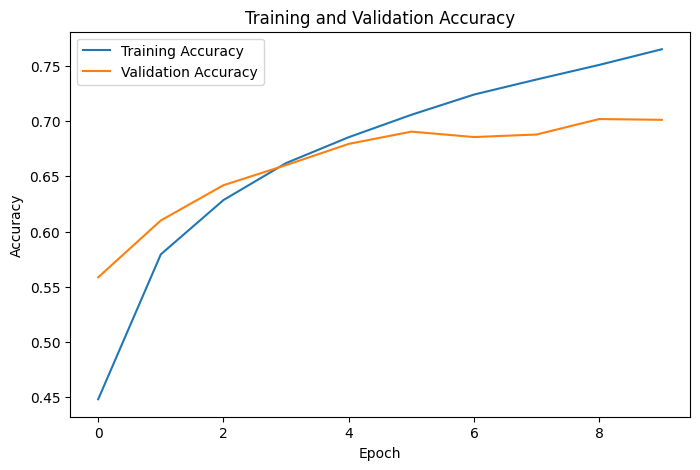

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## 11. Training and Validation Loss

The loss curves are plotted to assess model convergence and identify potential overfitting.

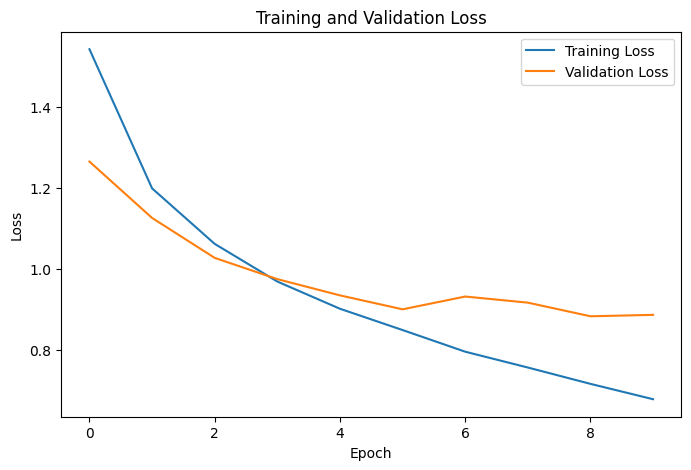

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## 12. Generating Predictions

Predictions are generated on the test dataset and converted into class labels for evaluation.

In [13]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = np.argmax(
    y_test,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


## 13. Classification Report

The classification report provides precision, recall, F1-score, and support metrics for each image class.

In [14]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.72      0.77      0.74      1000
  Automobile       0.86      0.77      0.81      1000
        Bird       0.68      0.51      0.58      1000
         Cat       0.56      0.41      0.48      1000
        Deer       0.67      0.66      0.67      1000
         Dog       0.51      0.73      0.60      1000
        Frog       0.81      0.74      0.77      1000
       Horse       0.74      0.77      0.75      1000
        Ship       0.77      0.83      0.80      1000
       Truck       0.75      0.82      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



## 14. Confusion Matrix

The confusion matrix visualizes the relationship between actual and predicted classes, highlighting classification strengths and errors.

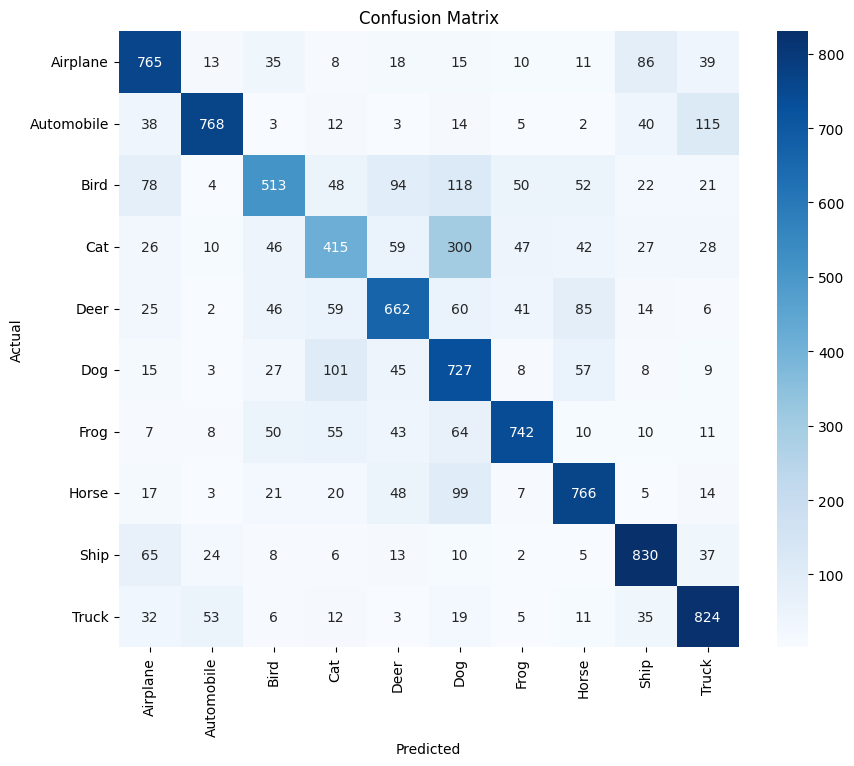

In [15]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

# 15. Project Summary

## Problem Statement

The objective of this project was to develop a Computer Vision model capable of classifying images from the CIFAR-10 dataset into ten object categories using a Convolutional Neural Network (CNN).

## Approach Used

The CIFAR-10 dataset was loaded and explored to understand its structure and class distribution. Image preprocessing was performed by normalizing pixel values and one-hot encoding the target labels. A Convolutional Neural Network consisting of convolutional layers, max-pooling layers, a flatten layer, and dense layers was developed and trained to classify images into ten categories.

## Model Performance

The CNN achieved a training accuracy of 76.51% and a test accuracy of 70.12%, with a test loss of 0.8874. The model demonstrated a good ability to learn image features and generalize to previously unseen data.

## Key Observations and Lessons Learned

- Convolutional Neural Networks are effective for image classification tasks.
- Image normalization improved training efficiency and model convergence.
- Max-pooling layers helped reduce computational complexity while preserving important image features.
- The model achieved reasonable performance on unseen test images, indicating successful feature learning.
- Some classes with similar visual characteristics may be more challenging to distinguish, contributing to classification errors.
- Monitoring accuracy and loss curves is important for detecting overfitting and evaluating model performance.